# An Annotated Implementation of the HHL Algorithm [[1]](#1)
In this notebook, we will describe and step through a Qiskit circuit implementing the HHL algorithm for solving linear systems on a quantum computer.  
To be specific, we are trying to solve for $\vec{x}$ in a matrix equation $$ A\vec{x}=\vec{b} $$ where both $A$ and $b$ are known and (we assume) available to represent on the computer as needed. We also assume the matrix $A$ is indeed invertible, so it has no zero eigenvalues, and we will not treat negative eigenvalues at this time either.

The essence of the algorithm is as follows: we are trying to compute $A^{-1}\vec{b}$, and the central observation is that by decomposing $\vec{b}$ into the eigenbasis of $A$ (or if you prefer, viewing it as a superposition of eigenvectors), the action of the inverse becomes diagonal, just dividing by the eigenvalues of $A$ instead of multiplying on each eigenvector.  

We can obtain the eigenvalues of $A$ in two steps: first, assuming $A$ is self-adjoint/Hermitian, we want to implement the unitary (which it is when $A$ is Hermitian) $U=e^{iAt}$ for some appropriate $t\in\mathbb{R}$. This means the eigenvalues of $A$ will appear as phases in the action of $U$ on the eigenbasis of $A$ (which is also the eigenbasis of $U$). (If $A$ is not Hermitian, it is easy to construct a block matrix containing $A$ which is Hermitian and has the desired equation associated to one of its blocks.)

This is the setting for Quantum Phase Estimation to extract the eigenvalues of $A$ and encode them each (approximately) into a bitstring $|\tilde\lambda_k\rangle^C$. We can then do arithmetic on those bitstrings to compute functions of the eigenvalues; specifically, we want to rotate a flag qubit $S$ so that the amplitude of $|1\rangle^S|\tilde\lambda_k\rangle^C$ is proportional to $1/\tilde\lambda_k$, which corresponds to the action of $A^{-1}$. 

Once we clean up the computation, we have (approximately) carried out the inversion $A^{-1}\vec{b}$ and have the (normalized) solution $|x\rangle^I$ in our register. At this point we can repeat the process to approximate its bits, or compute some observable in a single step.

Let's get our importing out of the way and define the problem in a simple case.

In [151]:
from qiskit.circuit import QuantumCircuit, QuantumRegister, AncillaRegister, ClassicalRegister, Parameter
from qiskit.quantum_info import Statevector, Operator
from qiskit.circuit.library import HamiltonianGate, QFTGate, UnitaryGate, phase_estimation
from qiskit.circuit.library.arithmetic.piecewise_chebyshev import PiecewiseChebyshev
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp

Writing a $2\times2$ system, we only need one qubit to encode $b$; but since states are normalized, the representations $|b\rangle^I$ and $|x\rangle^I$ are normalized as well.


In [152]:
evals = [1,2]
A = np.diag(evals)
b = [1,2] # solution should be x = [1,1]
ket_b = b/np.linalg.norm(b)
kappa = max(np.abs(evals))/min(np.abs(evals)) # "condition number" for the matrix; large kappa means inversion is not well behaved. Relevant for error analysis.
data_qubits = int(np.log2(len(b))) # assuming the input data is already suitable to be represented exactly on qubits; embed in larger matrix otherwise

We need to define the unitary exponentiating $A$, which means we need to pick the parameter $t$. Its role is to stop the phases we estimate from being too large, and accordingly it should be inverse to the eigenvalues in some sense. See for example [[2]](#2). There are methods to estimate this in some cases, but we will exploit our knowlege of the problem.

In [153]:
t = np.pi/max(np.abs(evals))
Unitary = HamiltonianGate(A,t,label="Evolution").control(1)
print("t =",t)

t = 1.5707963267948966


The details of the circuit naturally depend on the problem, so we have to do some precomputation, mainly concerning the rotation of the flag $S$. See [[2]](#2) for theory. The rotation is achieved using a Chebyshev polynomial approximation (bulit into Qiskit) of the desired angle function, which implements those polynomials using a sequence of rotation gates.

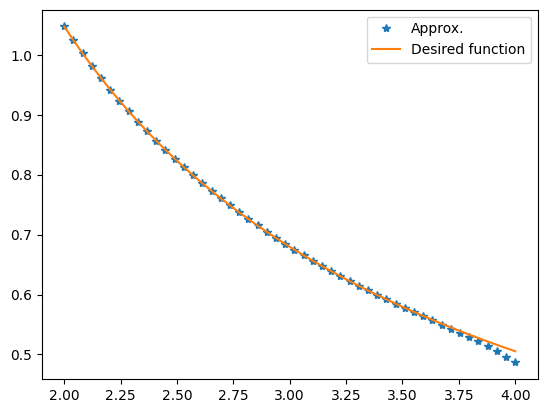

In [154]:
eps = 0.01 # error in solution due to inversion: 'eps_R' in [2]. Here only used for polynomial degrees. Using 0.1 causes one of the final values to be rounded a little.
qpe_qubits = int(np.ceil(np.log2(kappa+1))) # size of the C register, for the QPE step : encodes eigenvalues, and holds polynomial outputs : 'n_l' in [2]
                                            # this says we use more qubits depending on the range separating our eigenvalues, at least
                                            # this formula is not from [2], but the referenced repository [3], which still broadly implements [2]
                                            # [2] has a formula (43) which uses eps_R, but it presented difficulty here

C_range = 2**qpe_qubits # 'N_l' in [2]
constant = C_range * t * min(evals) / (2*np.pi) # 'C' in [2]
interval_start = int(round(qpe_qubits ** (2 / 3))) # the starting point of a sequence of exponentially growing intervals to cover the relevant bitstrings; 'a' in [2]
                                                   # QPE bitstrings \tilde\lambda_k should lie between interval_start and C_range-1; not about the original \lambda_k

r = 2 * constant / interval_start + np.sqrt(np.abs(1 - (2 * constant / interval_start) ** 2))
degree = int(   np.log(1 + ( 16.23 * np.sqrt(np.log(r) ** 2 + (np.pi / 2) ** 2) * kappa * (2 * kappa - eps) )
                / eps )   ) # degree of upcoming polynomials
num_intervals = int(np.ceil(np.log((C_range - 1) / interval_start) / np.log(5)))

# exponential breakpoints from 'a' progression above
breakpoints = []
for i in range(0, num_intervals):
    breakpoints.append(interval_start * (5**i))

    # last interval is truncated at the max value storable in the C_clock
    if i == num_intervals - 1:
        breakpoints.append(C_range-1)

reciprocal_circuit = PiecewiseChebyshev(lambda x: np.arcsin(constant / x), num_state_qubits=qpe_qubits, degree=degree, breakpoints=breakpoints)
ChebPolyRotation = reciprocal_circuit.to_gate()
ChebPolyRotation.label = "Eigenvalue Inverse Rotation"

polynomials = []
x=np.linspace(interval_start, C_range)
for poly in reciprocal_circuit.polynomials[1:-1]: # These indices avoid plotting unrelated constants filling gaps where inputs shouldn't be anyway; see PwCheb docs.
    polynomials.append(np.polynomial.Polynomial(poly))
for poly in polynomials:
    plt.plot(x,poly(x), label="Approx.", ls = '', marker = '*')
plt.plot(x,np.arcsin(constant/x)*2, label="Desired function") # factor of two is for Qiskit angle convention
plt.legend()
plt.show() # see the approximation being used

Now we can build the circuit. At each stage we draw the circuit and provide the statevector for reference.

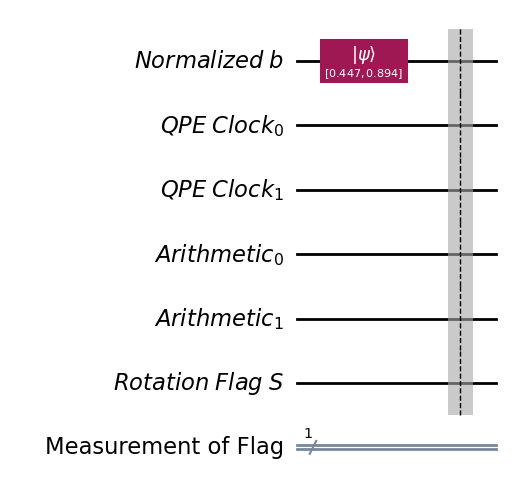

<IPython.core.display.Latex object>

In [155]:
I_data = QuantumRegister(size=data_qubits, name="Normalized b")
C_clock = AncillaRegister(size=qpe_qubits, name="QPE Clock")
A_computation = AncillaRegister(reciprocal_circuit.num_ancillas, name="Arithmetic")
S_flag = AncillaRegister(size=1, name="Rotation Flag S")
M_measured = ClassicalRegister(size=1, name="Measurement of Flag")

HHL = QuantumCircuit(I_data, C_clock, A_computation, S_flag, M_measured)
HHL.initialize(ket_b, I_data)
HHL.barrier()
display(HHL.draw(output="mpl"))
display(Statevector(HHL).draw("latex"))

Now we add the QPE stage:

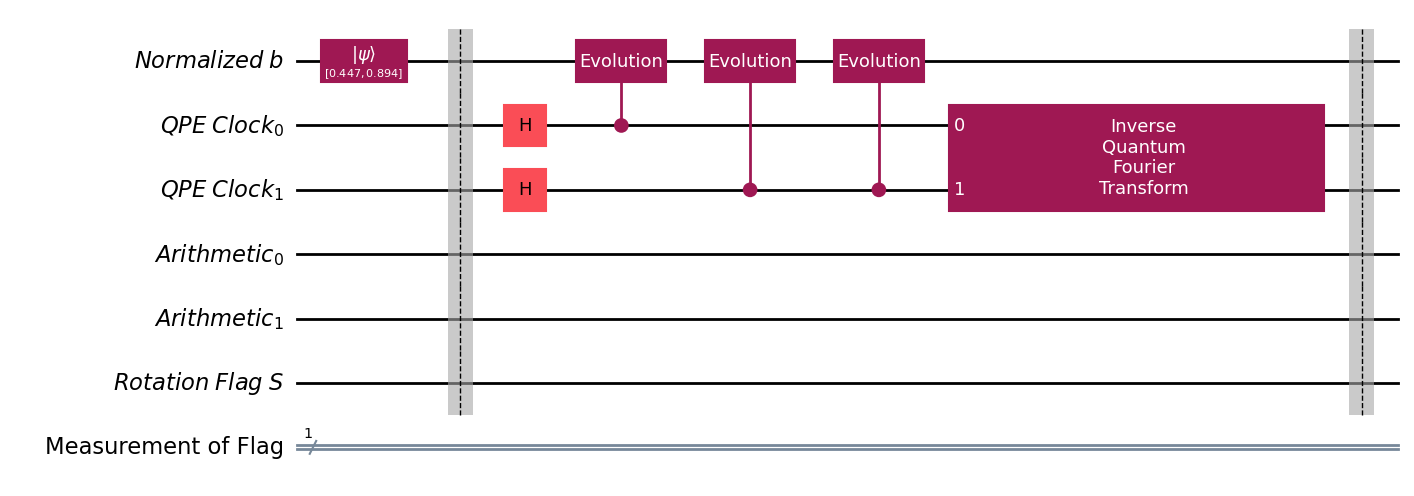

<IPython.core.display.Latex object>

In [156]:
QFT = QFTGate(num_qubits=qpe_qubits)
QFT.label = "Quantum\nFourier\nTransform"
QFTdg = QFT.inverse()
QFTdg.label = "Inverse\nQuantum\nFourier\nTransform"
HHL.h(C_clock)
repetitions = 1 # loop structure from Qiskit textbook QPE
for i in range(len(C_clock)):
    for _ in range(repetitions):
        HHL.append(Unitary, [data_qubits+i]+I_data[:]) # This is CU, repetitions increment power according to bitstrings
    repetitions *= 2
HHL.append(QFTdg, C_clock)
HHL.barrier()
display(HHL.draw(output="mpl",fold=-1))
display(Statevector(HHL).draw("latex"))

Now we rotate the flag S by an angle computed from the eigenvalues encoded in the clock, based on the Chebyshev approximation carried out above. Notice this gate takes the S flag as the middle input, but it is the bottom wire for us, so its input indices are out of order.

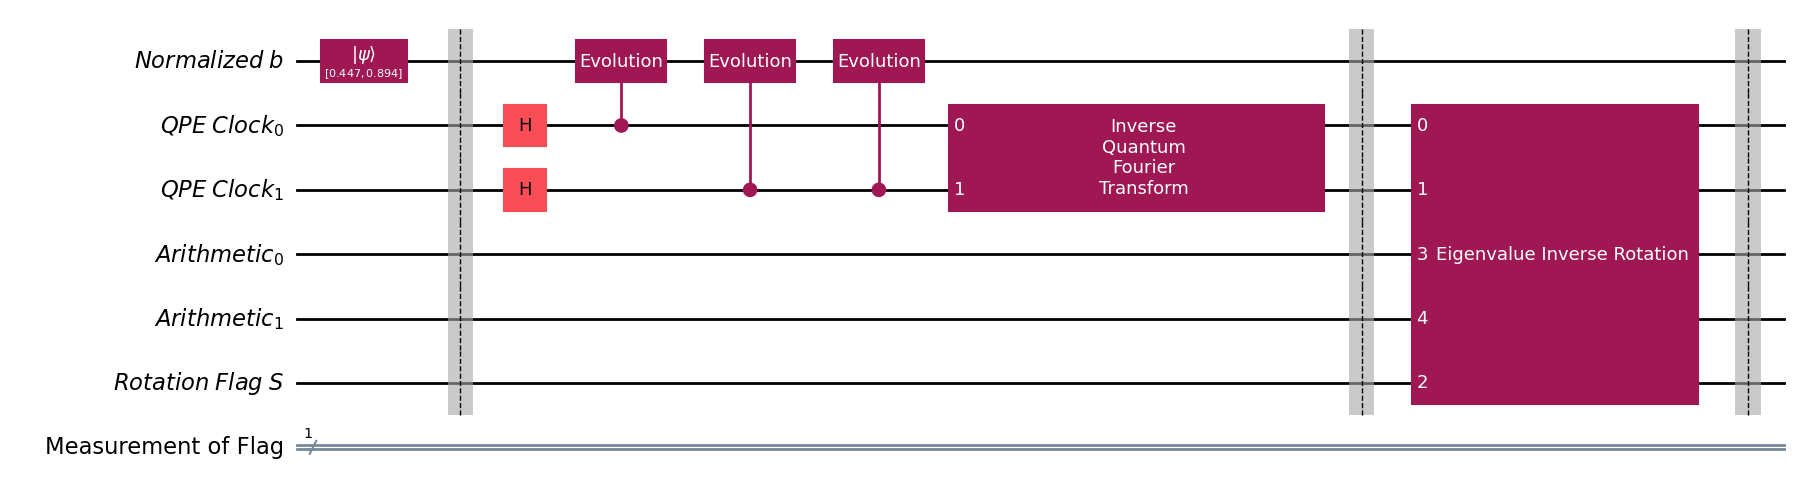

<IPython.core.display.Latex object>

In [157]:
HHL.append(ChebPolyRotation, C_clock[:] + S_flag[:] + A_computation[:])
HHL.barrier()
display(HHL.draw(output="mpl",fold=-1))
display(Statevector(HHL).draw("latex"))

Now we reverse the QPE; if the flag is 1, the state left in the input register should be proportional to the solution $\vec{x}$

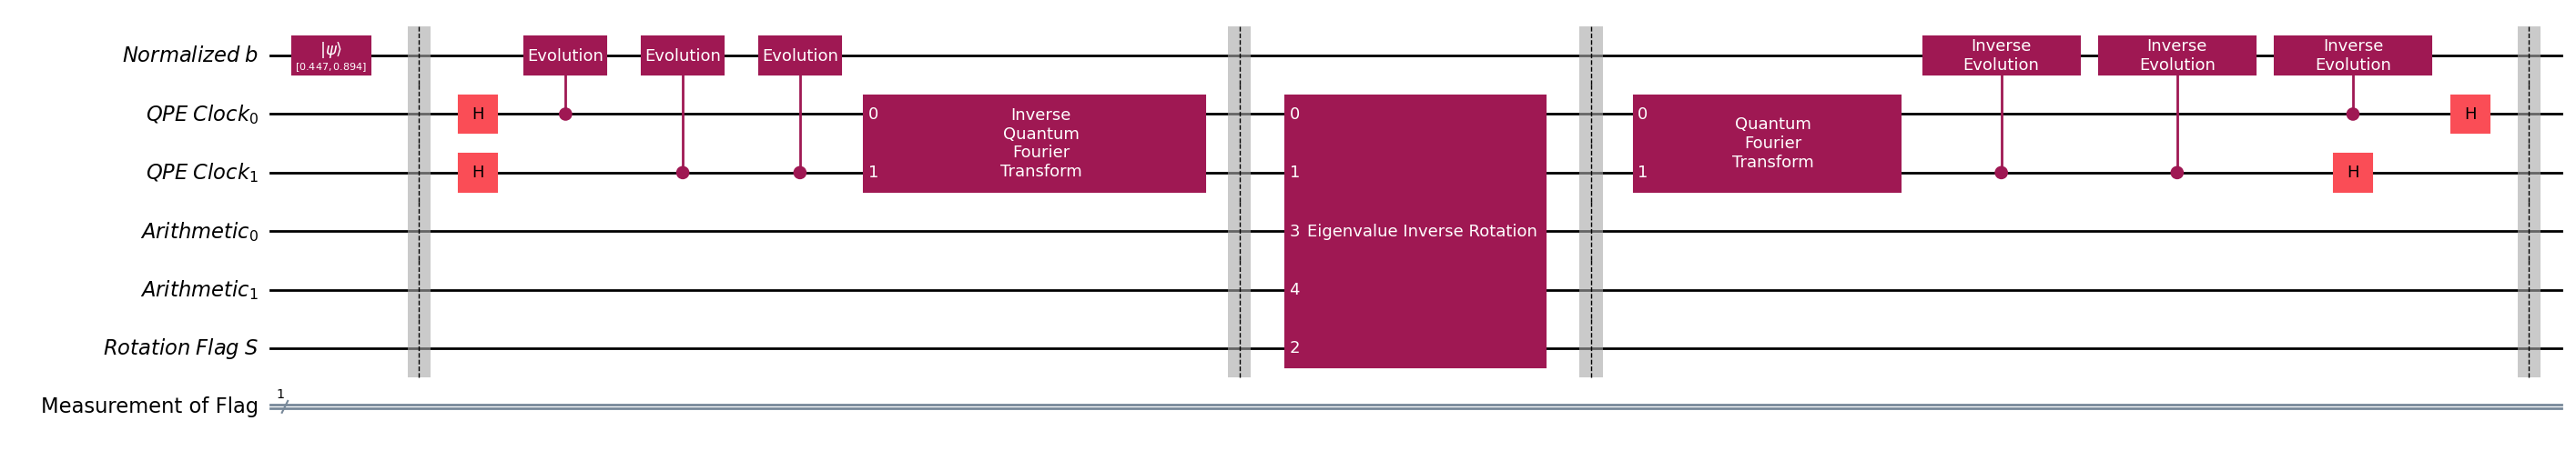

<IPython.core.display.Latex object>

In [158]:
Udg = HamiltonianGate(A,t).inverse()
Udg.label = "Inverse\nEvolution"
CUdg = Udg.control(1)
HHL.append(QFT,C_clock)
repetitions = int(repetitions/2) # cancel extra increase in last step above
for i in range(len(C_clock)):
    for _ in range(repetitions):
        HHL.append(CUdg, [data_qubits+qpe_qubits-i-1]+I_data[:])
    repetitions = int(repetitions/2)
HHL.h(C_clock)
HHL.barrier()
display(HHL.draw(output="mpl",fold=-1))
display(Statevector(HHL).draw("latex"))

Notice that, conditioned on measuring 1 out of the S flag qubit (displayed first in the ket), the resulting state is evenly split:$$|1\rangle^S|00\rangle^A|00\rangle^C\left(\frac{1}{\sqrt{2}}|0\rangle^I+\frac{1}{\sqrt{2}}|1\rangle^I\right)$$ which encodes the answer because the I qubit has equal amplitudes:
$$|x\rangle^I=\left(\frac{1}{\sqrt{2}}|0\rangle^I+\frac{1}{\sqrt{2}}|1\rangle^I\right)=\begin{pmatrix}1/\sqrt{2}\\1/\sqrt{2}\end{pmatrix}\propto\begin{pmatrix}1\\1\end{pmatrix}=\vec{x}\text{ solving } \begin{pmatrix}1&0\\0&2\end{pmatrix}\vec{x}=\begin{pmatrix}1\\2\end{pmatrix}=\vec{b}$$

## Comments and options for improvement
This shows the 'HHL' part of the algorithm, but in principle a lot is happing to arrive at the Evolution unitary (Hamiltonian Simulation) and Qiskit's PiecewiseChebyshev does a lot to actually execute the desired rotation. It would be nice to present those components as well, if not big-picture instructive.

This code appears to respond well to non-diagonal self-adjoint matrices, i.e. conjugating $A$ by a unitary, though some error begins to creep in after a few decimal places; but only as long as the eigenvalues are powers of two. This suggests a difficulty related to the encoding; one could inspect the statevectors to see where it diverges from theory, or try to force it to use more precision (see comments when defining eps). It also does not accomodate negative eigenvalues, which can be done with a sign bit to manage the resulting negative phases, as in [[3]](3).

It would also be appropriate to package the code so as to take input problems easily, and carry out the measuremnt step to fully demonstrate "getting an answer."

## References
<a id="1">[1]</a> 
Aram W. Harrow, Avinatan Hassidim, and Seth Lloyd. (2009).  
[Quantum Algorithm for Linear Systems of Equations](https://arxiv.org/abs/0811.3171v3).  
Phys. Rev. Lett. 103, 150502.

<a id="2">[2]</a> 
Almudena Carrera Vazquez, Ralf Hiptmair and Stefan Woerner. (2022).  
[Enhancing the Quantum Linear Systems Algorithm Using Richardson Extrapolation](https://arxiv.org/abs/2009.04484).  
ACM Transactions on Quantum Computing, Volume 3, Issue 1.

<a id="3">[3]</a> 
[Quantum linear solvers](https://github.com/anedumla/quantum_linear_solvers/blob/main/linear_solvers/hhl.py) on Github